<a href="https://colab.research.google.com/github/tristansalazar/MachineLearning-/blob/main/Unidad2/Practica5_U2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from IPython.display import Markdown, display

display(Markdown("""
# Machine Learning y Deep Learning

**Unidad 2**

**Práctica 5:** Máquinas de Soporte para Regresión (SVR)

**Facilitador:** *Dr. José Gabriel Rodríguez Rivas*

**Alumno:** Diego Tristán Salazar Rueda

## Máquinas de Soporte para Regresión (SVR)

**Cómo funciona**
- SVR busca una línea (o hiperplano en espacios multidimensionales) que se ajuste a los datos con la menor complejidad posible, es decir, que sea lo más plana posible, pero que también respete un margen de tolerancia.

**Características**
- Es una extensión de las máquinas de soporte vectorial (SVM) para problemas de regresión.
- Es **sensible a la escala de los datos**, por eso se **requiere escalamiento de los datos**.
- Intenta ajustar una función que tenga una desviación máxima **ε** permitida del valor real.

**Ventajas**
- Muy potente para relaciones no lineales.
- Robusto frente a outliers si se ajustan bien los parámetros.
- Muy eficaz para relaciones no lineales complejas.
- Buena generalización.

**Limitaciones**
- Lento en datasets grandes.
- Requiere cuidadosa selección de hiperparámetros y escalado de datos.

**Soporte vectorial:**
- Solo los puntos que caen fuera del margen ε (los que tienen errores significativos) influyen en el modelo. Estos puntos se llaman vectores de soporte.

**Kernels:**
- SVR puede usar funciones kernel (como el radial RBF, polinomial, etc.) para modelar relaciones no lineales entre las variables.

**Parámetros importantes en SVR**
- **C:** controla el compromiso entre el margen y el error. Valores altos permiten menos errores pero pueden sobreajustar.
- **ε:** define el margen de tolerancia. Valores pequeños hacen que el modelo sea más preciso pero más sensible al ruido.
- **kernel:** define la forma de la función de predicción (lineal, RBF, polinomial, etc.).
- **gamma:** afecta la forma del kernel (especialmente en RBF).

**Comparación con los modelos anteriores:**

| Técnica | Linealidad | Flexibilidad | Requiere Escalado | Overfitting | Interpretabilidad |
|---|---|---|---|---|---|
| Regresión Lineal | Alta | Baja | No | Baja | Alta |
| Árboles / RandomForest | Baja | Alta | No | Media-Baja | Media |
| SVR | Muy Baja | Alta | Sí | Baja | Baja |
"""))


# Machine Learning y Deep Learning

**Unidad 2**

**Práctica 5:** Máquinas de Soporte para Regresión (SVR)

**Facilitador:** *Dr. José Gabriel Rodríguez Rivas*

**Alumno:** Diego Tristán Salazar Rueda

## Máquinas de Soporte para Regresión (SVR)

**Cómo funciona**
- SVR busca una línea (o hiperplano en espacios multidimensionales) que se ajuste a los datos con la menor complejidad posible, es decir, que sea lo más plana posible, pero que también respete un margen de tolerancia.

**Características**
- Es una extensión de las máquinas de soporte vectorial (SVM) para problemas de regresión.
- Es **sensible a la escala de los datos**, por eso se **requiere escalamiento de los datos**.
- Intenta ajustar una función que tenga una desviación máxima **ε** permitida del valor real.

**Ventajas**
- Muy potente para relaciones no lineales.
- Robusto frente a outliers si se ajustan bien los parámetros.
- Muy eficaz para relaciones no lineales complejas.
- Buena generalización.

**Limitaciones**
- Lento en datasets grandes.
- Requiere cuidadosa selección de hiperparámetros y escalado de datos.

**Soporte vectorial:**
- Solo los puntos que caen fuera del margen ε (los que tienen errores significativos) influyen en el modelo. Estos puntos se llaman vectores de soporte.

**Kernels:**
- SVR puede usar funciones kernel (como el radial RBF, polinomial, etc.) para modelar relaciones no lineales entre las variables.

**Parámetros importantes en SVR**
- **C:** controla el compromiso entre el margen y el error. Valores altos permiten menos errores pero pueden sobreajustar.
- **ε:** define el margen de tolerancia. Valores pequeños hacen que el modelo sea más preciso pero más sensible al ruido.
- **kernel:** define la forma de la función de predicción (lineal, RBF, polinomial, etc.).
- **gamma:** afecta la forma del kernel (especialmente en RBF).

**Comparación con los modelos anteriores:**

| Técnica | Linealidad | Flexibilidad | Requiere Escalado | Overfitting | Interpretabilidad |
|---|---|---|---|---|---|
| Regresión Lineal | Alta | Baja | No | Baja | Alta |
| Árboles / RandomForest | Baja | Alta | No | Media-Baja | Media |
| SVR | Muy Baja | Alta | Sí | Baja | Baja |


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("autos2.csv")
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,peak-rpm,city-mpg,highway-L/100km,price,city-L/100km,fuel-type_code,diesel,gas,fuel-type-map,horsepower-binned
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,13495.0,11.190476,1,False,True,1,Low
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,16500.0,11.190476,1,False,True,1,Low
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,5000.0,19,9.038462,16500.0,12.368421,1,False,True,1,Medium
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,5500.0,24,7.833333,13950.0,9.791667,1,False,True,1,Low
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,5500.0,18,10.681818,17450.0,13.055556,1,False,True,1,Low


In [3]:
X = df[['horsepower', 'engine-size', 'city-mpg', 'wheel-base', 'bore']]
y = df['price']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

In [6]:
X_train

,horsepower,engine-size,city-mpg,wheel-base,bore
198,134,173,18,109.1,3.58
38,86,110,27,96.5,3.15
24,68,90,31,93.7,2.97
122,143,151,19,94.5,3.94
196,114,141,23,109.1,3.78
...,...,...,...,...,...
106,97,120,19,114.2,3.46
14,182,209,16,103.5,3.62
92,69,97,31,94.5,3.15
179,85,109,27,97.3,3.19


In [7]:
svr_model = SVR(kernel='rbf', C=100, epsilon=0.2)
svr_model.fit(X_train_scaled, y_train_scaled)

SVR(C=100, epsilon=0.2)

In [8]:
y_pred_scaled = svr_model.predict(X_test_scaled)

y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))

mse_svr = mean_squared_error(y_test, y_pred)
r2_svr = r2_score(y_test, y_pred)

print(f"Error cuadrático medio (MSE): {mse_svr:.2f}")
print(f"Coeficiente de determinación (R²): {r2_svr:.2f}")

Error cuadrático medio (MSE): 19050289.52
Coeficiente de determinación (R²): 0.84


In [9]:
rmse = np.sqrt(mse_svr)
print(f"Raíz del Error cuadrático medio (RMSE): {rmse:.2f}")

Raíz del Error cuadrático medio (RMSE): 4364.66


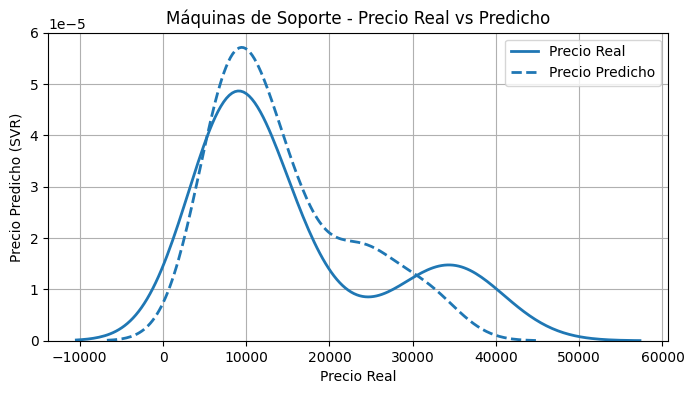

In [10]:
plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred, label='Precio Predicho', linewidth=2, linestyle='--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho (SVR)")
plt.title("Máquinas de Soporte - Precio Real vs Predicho")
plt.grid(True)
plt.legend()
plt.show()

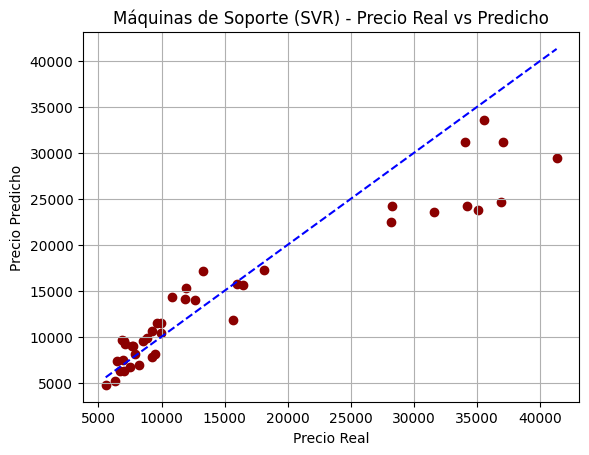

In [11]:
plt.scatter(y_test, y_pred, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Máquinas de Soporte (SVR) - Precio Real vs Predicho")
plt.grid(True)
plt.show()

In [12]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 1],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1]
}

grid_search = GridSearchCV(SVR(), param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train_scaled)

best_svr = grid_search.best_estimator_
print("\n Mejores parámetros encontrados:")
print(grid_search.best_params_)

y_pred_scaled = best_svr.predict(X_test_scaled)

y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n Resultados del mejor modelo:")
print(f"Error cuadrático medio (MSE): {mse:.2f}")
print(f"Coeficiente de determinación (R²): {r2:.2f}")
print(f"Raíz del error cuadrático medio (RMSE): {np.sqrt(mse):.2f}")

Fitting 3 folds for each of 180 candidates, totalling 540 fits

 Mejores parámetros encontrados:
{'C': 10, 'epsilon': 0.01, 'gamma': 0.1, 'kernel': 'rbf'}

 Resultados del mejor modelo:
Error cuadrático medio (MSE): 23658789.30
Coeficiente de determinación (R²): 0.81
Raíz del error cuadrático medio (RMSE): 4864.03
